# Python fundamentals for the Weekly ETF Risk Monitor

**Author:** Paritosh Dwivedi

## Audience, prerequisites, and learning goals

This tutorial records the Python, NumPy, and pandas foundations used by the cumulative project. It assumes basic Python syntax and a working project environment.

By the end, the reader can:

1. choose suitable Python data structures;
2. replace avoidable loops with NumPy vectorization;
3. inspect, group, and summarize tabular market-like data;
4. import a reusable function from `src/`.

## Tutorial outline

1. Reproducible setup
2. Core Python structures and functions
3. NumPy vectorization
4. pandas inspection and aggregation
5. A small visualization
6. Reusable project utilities
7. Exercise, pitfalls, and extensions

In [1]:
# --- run me first ---
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import clean_column_name

np.random.seed(42)
print("working from:", ROOT.name)

working from: project


## 1. Core Python structures and functions

Lists preserve ordered observations, dictionaries attach meaning to values, and functions make repeated calculations explicit and testable.

In [2]:
weekly_returns = [0.012, -0.008, 0.004, 0.015, -0.003]
position = {
    "ticker": "SPY",
    "units": 100,
    "review_frequency": "weekly",
}


def compound_return(returns):
    # Compound decimal returns over a period.
    return np.prod(1 + np.asarray(returns)) - 1


print(position)
print(f"Compounded return: {compound_return(weekly_returns):.2%}")

{'ticker': 'SPY', 'units': 100, 'review_frequency': 'weekly'}
Compounded return: 2.00%


## 2. NumPy vectorization

Vectorized operations apply a transformation to an entire array. They are usually clearer and faster than row-by-row Python loops for numerical work.

In [3]:
prices = np.array([100.0, 101.5, 100.8, 102.4, 103.1])
vectorized_returns = prices[1:] / prices[:-1] - 1
loop_returns = np.array([prices[i] / prices[i - 1] - 1 for i in range(1, len(prices))])

assert np.allclose(vectorized_returns, loop_returns)
vectorized_returns

array([ 0.015     , -0.00689655,  0.01587302,  0.00683594])

## 3. pandas inspection and aggregation

The example below uses small, deterministic market-like data. `.info()`, `.describe()`, and missing-value counts are fast first checks before analysis.

In [4]:
sample = pd.DataFrame(
    {
        "date": pd.date_range("2026-08-03", periods=10, freq="B"),
        "ticker": ["SPY"] * 5 + ["QQQ"] * 5,
        "return": [0.004, -0.002, 0.007, 0.001, -0.003, 0.006, -0.009, 0.010, 0.002, -0.004],
        "volume_millions": [72, 68, 81, 66, 75, 49, 57, 64, 51, 55],
    }
)

print(sample.dtypes)
display(sample.head())
display(sample[["return", "volume_millions"]].describe().round(3))
print("missing values:", int(sample.isna().sum().sum()))

date               datetime64[ns]
ticker                     object
return                    float64
volume_millions             int64
dtype: object


,date,ticker,return,volume_millions
0,2026-08-03,SPY,0.004,72
1,2026-08-04,SPY,-0.002,68
2,2026-08-05,SPY,0.007,81
3,2026-08-06,SPY,0.001,66
4,2026-08-07,SPY,-0.003,75


,return,volume_millions
count,10.000,10.000
mean,0.001,63.800
std,0.006,10.633
min,-0.009,49.000
25%,-0.003,55.500
50%,0.002,65.000
75%,0.006,71.000
max,0.010,81.000


missing values: 0


## 4. Grouping and interpretation

Grouping answers a comparative question while retaining readable labels.

In [5]:
summary = (
    sample.groupby("ticker")
    .agg(
        mean_return=("return", "mean"),
        return_volatility=("return", "std"),
        mean_volume_millions=("volume_millions", "mean"),
    )
    .reset_index()
)
display(summary.round(4))

,ticker,mean_return,return_volatility,mean_volume_millions
0,QQQ,0.0010,0.0076,55.2
1,SPY,0.0014,0.0042,72.4


## 5. Small visualization

The chart gives a quick view of sign, magnitude, and timing. The cumulative project saves final figures under `reports/images/`.

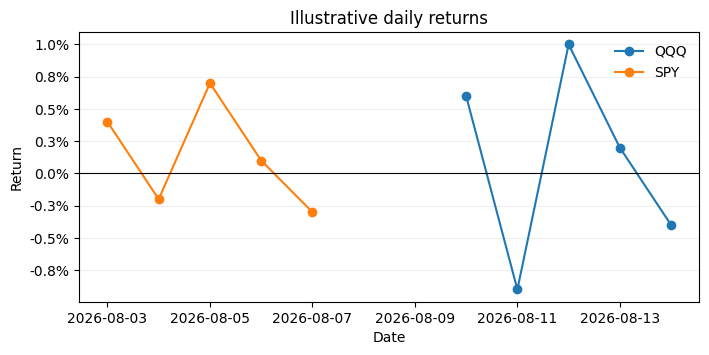

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for ticker, group in sample.groupby("ticker"):
    ax.plot(group["date"], group["return"], marker="o", label=ticker)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Illustrative daily returns", ylabel="Return", xlabel="Date")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.show()

## 6. Reusable utility

Reusable behavior belongs in `src/`. The notebook imports and demonstrates the project column-name cleaner instead of copying its implementation.

In [7]:
raw_labels = ["Adjusted Close", "Volume ($)", "Review Date"]
[clean_column_name(label) for label in raw_labels]

['adjusted_close', 'volume', 'review_date']

## 7. Exercise

Create a function that returns annualized volatility from decimal daily returns using 252 trading days. Then compare SPY and QQQ in the sample.

In [8]:
def annualized_volatility(daily_returns):
    values = np.asarray(daily_returns, dtype=float)
    return values.std(ddof=1) * np.sqrt(252)


exercise_answer = sample.groupby("ticker")["return"].apply(annualized_volatility)
exercise_answer.map(lambda value: f"{value:.1%}")

ticker
QQQ    12.1%
SPY     6.6%
Name: return, dtype: object

## Pitfalls and extension

- **Pitfall:** a random train/test split would mix later market information into an earlier evaluation. The cumulative project uses chronological splits.
- **Pitfall:** mutating a shared DataFrame can create hidden notebook state. Project functions return copies.
- **Extension:** replace the dummy data with a validated raw snapshot, then move repeated transformations into `src/features.py`.

The cumulative project notebook applies these foundations to the full SPY pipeline.